# 2 · The sensors, and one scenario

How the simulated radar, links, gauges and PWS see the truth, with the errors that dominate
each in practice; then one scenario with every sensor and every map. About two minutes.

1. The radar: band, attenuation, beam, range
2. The links: why wet/dry classification matters
3. Gauges and personal weather stations
4. One scenario, every map

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from core import viz_style as vs
%matplotlib inline
vs.use_style()
pd.set_option("display.width", 160)
FIG = Path("../results/figures")
TAB = Path("../results/tables")

from core.simulation import generators as gen, sensors as sn, spacetime as st, benchmark as bm
from core.simulation.rain_fields import Grid
from core.simulation.scenario import Scenario

## 1. The radar

The same rain (heavy convective cells), seen by S-, C- and X-band radars 20 km south-west of
the domain without attenuation correction, and by an X-band radar with dual-polarisation
correction (85% of the path-integrated attenuation restored).

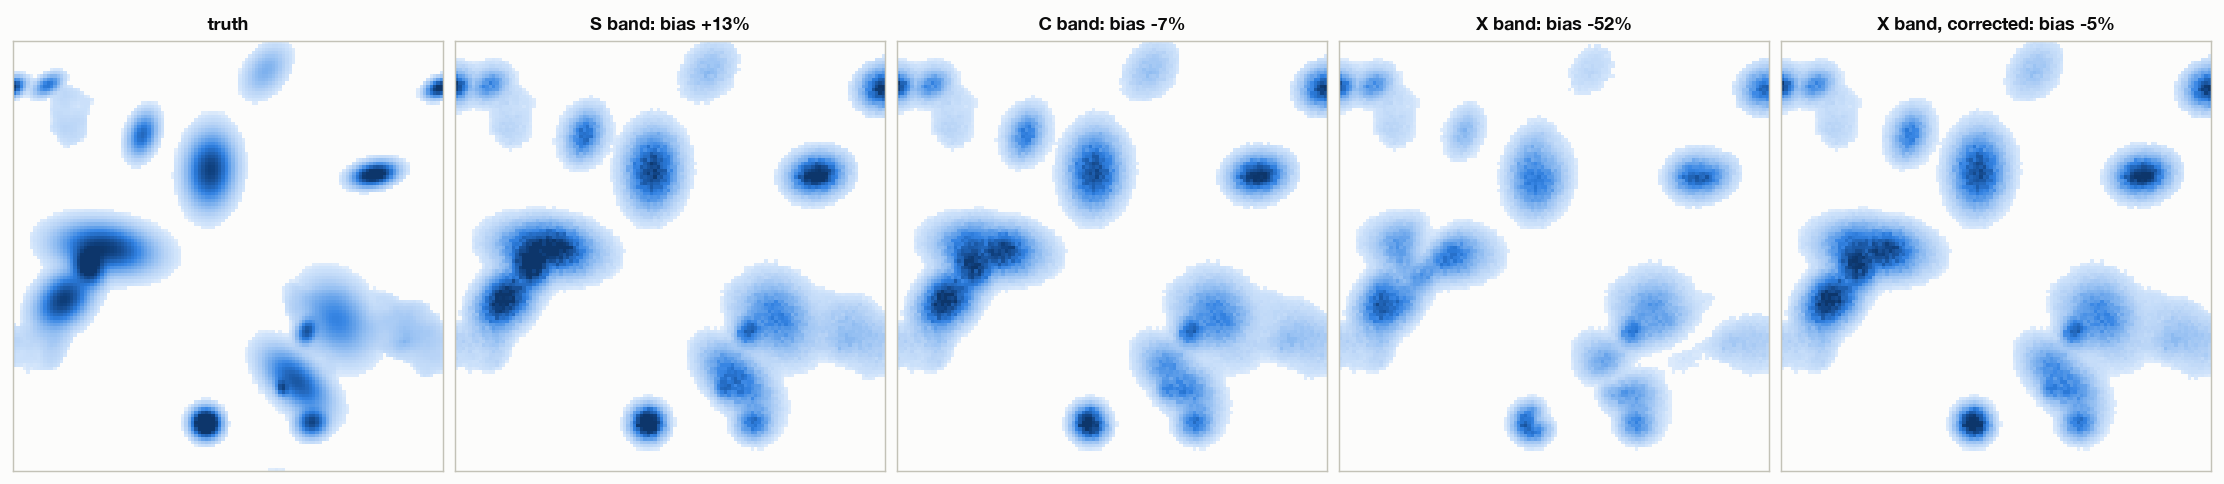

In [2]:
grid = Grid(n=128, dx_km=0.5)
seq = st.simulate(gen.make("convective_cells", seed=2, peak_mean_mm_h=45), grid, 6, 1.0, evolution="frozen")
truth = seq.frames[5] * 5 / 60
common = dict(dsd_sigma_db=1.5, site_km=(-20, -20), resolution_km=0.5)
radars = {"S band": sn.RadarConfig(band="S", **common), "C band": sn.RadarConfig(band="C", **common),
          "X band": sn.RadarConfig(band="X", **common),
          "X band, corrected": sn.RadarConfig(band="X", pia_correction=0.85, **common)}
obs = {k: sn.Radar(c, grid).observe(seq.frames, 1.0, 5.0)[0] for k, c in radars.items()}
fig, axes = plt.subplots(1, 5, figsize=(17, 3.6), layout="constrained")
for ax, (k, f) in zip(axes, [("truth", truth)] + list(obs.items())):
    ax.imshow(f, origin="lower", extent=(0, 64, 0, 64), cmap=vs.CMAP_RAIN, norm=vs.rain_norm(4))
    ax.set_title(k if k == "truth" else f"{k}: bias {f.sum() / truth.sum() - 1:+.0%}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

Behind heavy cells the uncorrected X band loses half the rain (the shadows point away from
the radar in the south-west); C band loses a few percent. The S band, hardly attenuated, reads
high instead: with 1.5 dB of DSD noise, averaging reflectivity in linear units and inverting a
power law over-reads (Jensen's inequality). The dual-polarisation correction brings the X band
back to within a few percent.

## 2. The links

Each link reports the path integral of `k R^alpha` plus wet-antenna attenuation, a baseline
offset, noise and quantisation. Retrieving every sample from the raw attenuation turns offsets
and noise into rain; the standard chain classifies wet and dry periods first (rolling standard
deviation) and takes the baseline from the preceding dry period.

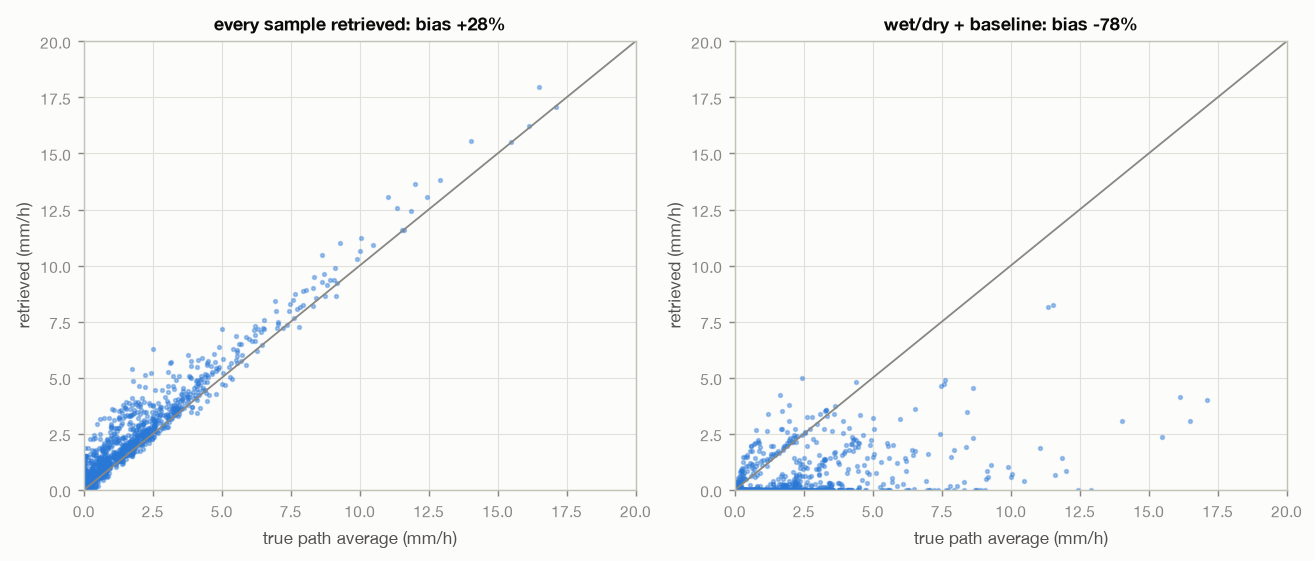

In [3]:
frames = st.simulate(gen.make("scale_free", seed=4), grid, 121, 1.0, evolution="ar1", tau_min=60).frames
out = {}
for name, p in {"every sample retrieved": {"wet_dry": False}, "wet/dry + baseline": {}}.items():
    o = sn.CMLs(sn.CMLConfig(n_links=60, seed=3, **p), grid).observe(frames, 1.0, 5.0)
    out[name] = o
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), layout="constrained")
for ax, (name, o) in zip(axes, out.items()):
    t, r = o["true_mm"].ravel() * 12, o["rain_mm"].ravel() * 12
    ok = np.isfinite(r)
    ax.scatter(t[ok], r[ok], s=4, alpha=0.4, color=vs.SERIES["stratiform"])
    ax.plot([0, 20], [0, 20], color=vs.INK_MUTED, lw=1)
    ax.set_xlim(0, 20); ax.set_ylim(0, 20)
    ax.set_title(f"{name}: bias {np.nansum(r) / t[ok].sum() - 1:+.0%}", fontsize=10)
    ax.set_xlabel("true path average (mm/h)"); ax.set_ylabel("retrieved (mm/h)")

## 3. Gauges and personal weather stations

Gauges tip in 0.2 mm steps and catch ~5% less than falls; PWS tip at 0.1 mm, catch ~15% less
with a wide spread, and some are dead or stuck at zero.

In [4]:
g = sn.Gauges(sn.GaugeConfig(n=40, seed=1), grid).observe(frames, 1.0, 60.0)
p = sn.Gauges(sn.GaugeConfig(n=40, seed=2, **sn.PWS_DEFAULTS), grid).observe(frames, 1.0, 60.0)
pd.DataFrame({k: {"bias of hourly totals": f"{np.nansum(o['rain_mm']) / np.nansum(np.where(np.isfinite(o['rain_mm']), o['true_mm'], 0)) - 1:+.0%}",
                  "stations reporting zero all along": int((np.nan_to_num(o["rain_mm"]).sum(1) == 0).sum()),
                  "dead": int(np.isnan(o["rain_mm"][:, 0]).sum())} for k, o in {"gauges": g, "PWS": p}.items()})

,gauges,PWS
bias of hourly totals,-9%,-27%
stations reporting zero all along,1,5
dead,0,1


## 4. One scenario, every map

`Scenario.run()` simulates the truth and every sensor and returns the xarray data the map,
merging and nowcasting code of `core/` reads from real networks. `benchmark.maps` makes 27
products from it; `benchmark.score_maps` scores them against the truth.

In [5]:
case = Scenario(model="banded_anisotropic", flow="rotation", flow_params={"omega_deg_h": 25, "mean": (20, 5)},
                duration_min=90, n_links=120, n_gauges=25, n_pws=40, seed=7).run()
products = bm.maps(case)
scores = bm.score_maps(case, products)
scores[["method", "family", "nrmse", "corr", "rel_bias", "csi"]].sort_values("nrmse").round(2).head(12)

,method,family,nrmse,corr,rel_bias,csi
8,mul [gauges],radar adjusted,0.33,0.95,0.03,0.91
7,add [gauges],radar adjusted,0.34,0.95,-0.05,0.89
11,okrig_add [gauges],radar adjusted,0.34,0.95,-0.05,0.88
12,ked [gauges],radar adjusted,0.34,0.95,0.09,0.81
15,mul [links],radar adjusted,0.35,0.95,-0.07,0.89
22,mul [links+gauges],radar adjusted,0.35,0.95,-0.05,0.89
9,idw_add [gauges],radar adjusted,0.35,0.95,-0.03,0.88
6,mfb [gauges],radar adjusted,0.35,0.95,-0.11,0.89
0,radar,radar only,0.36,0.95,0.08,0.91
21,add [links+gauges],radar adjusted,0.46,0.92,-0.22,0.75


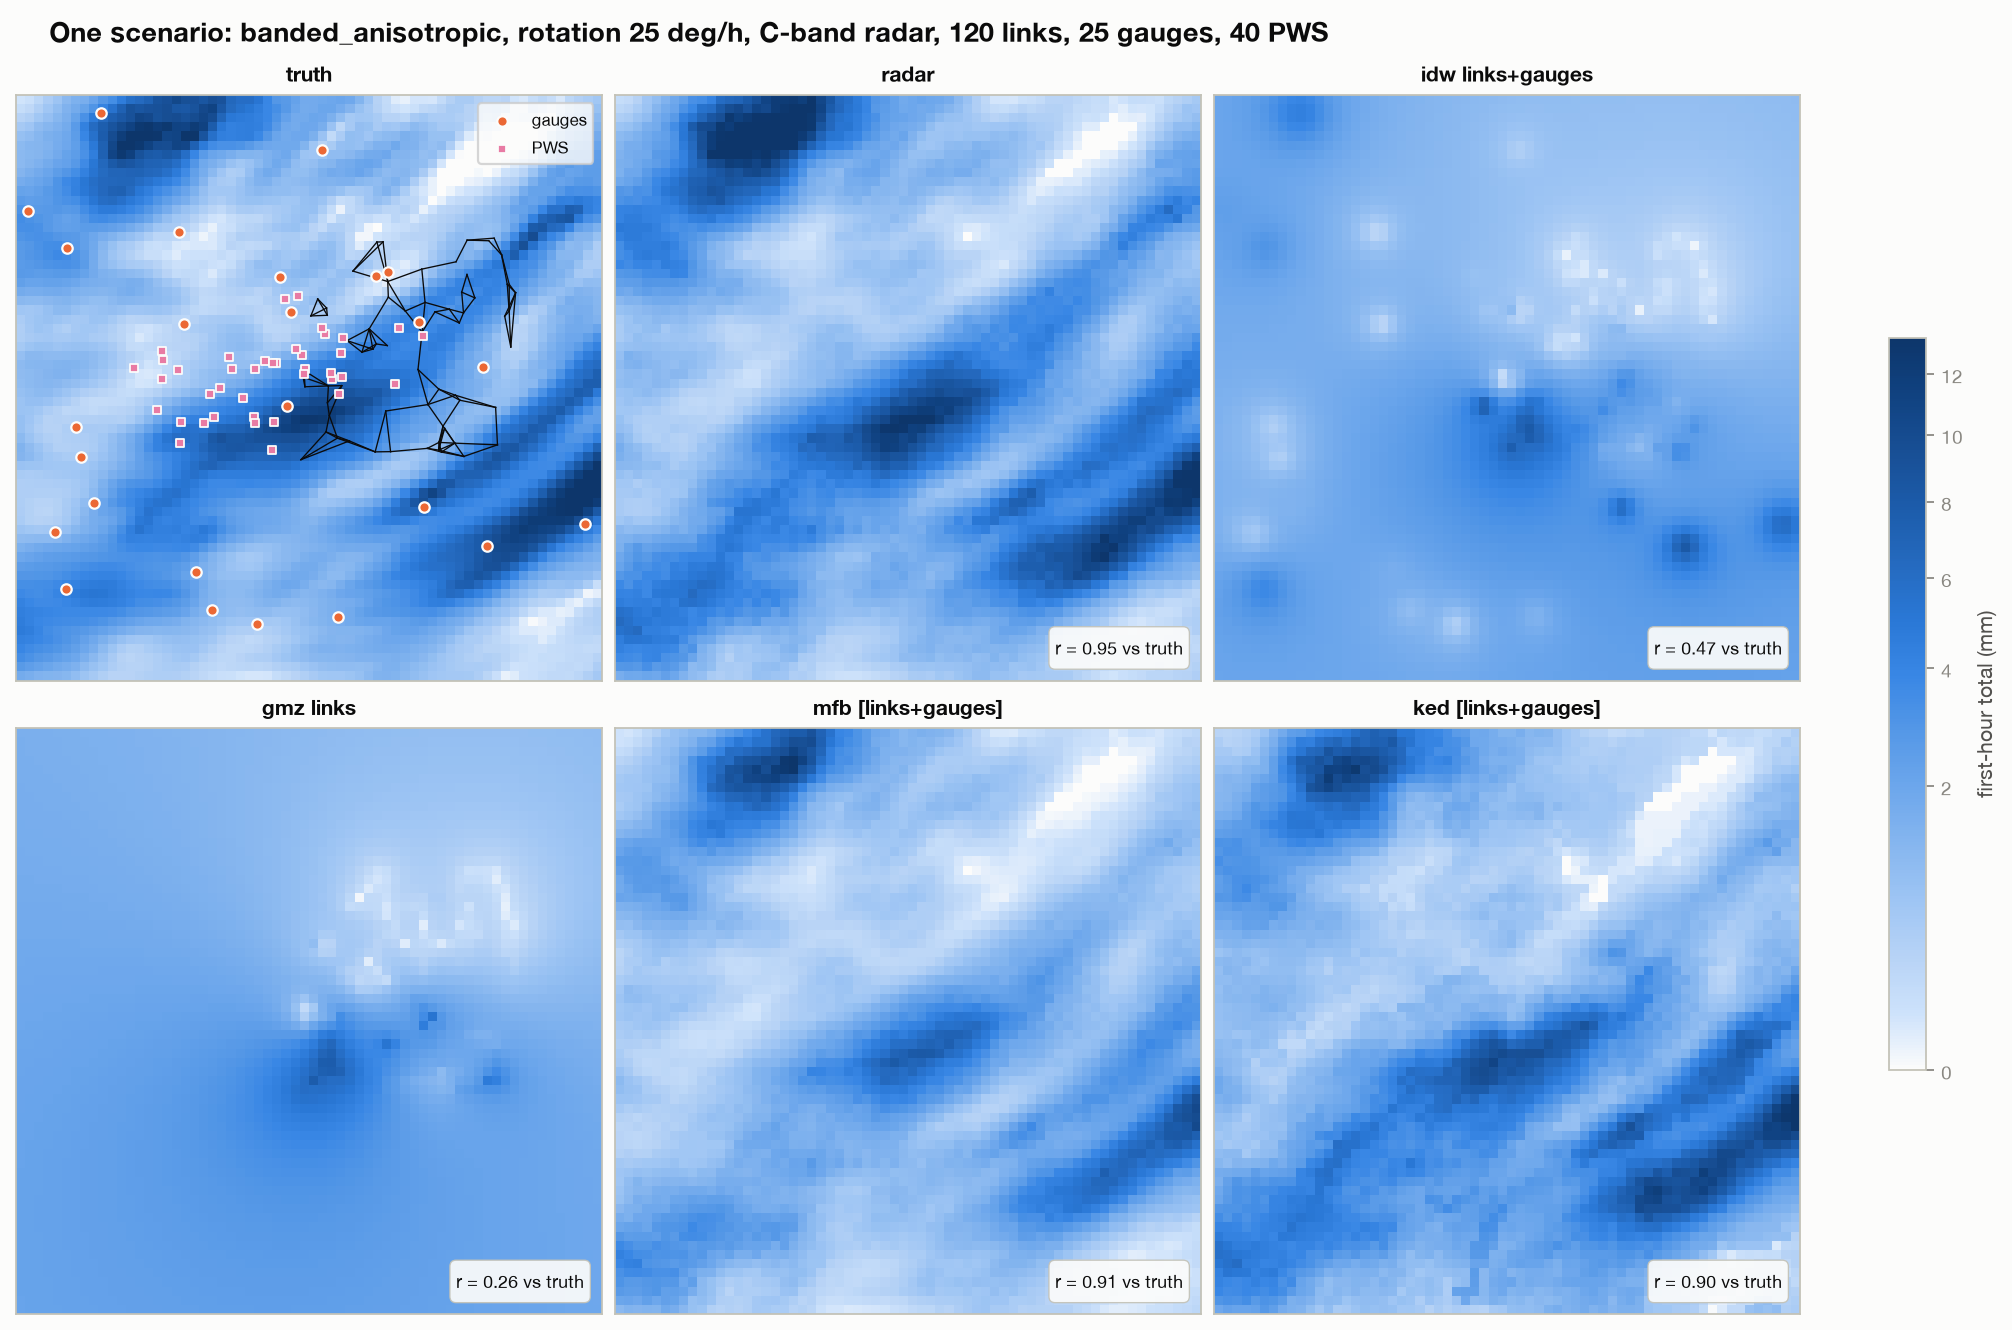

In [6]:
from synthetic_testbed import figures as fg
%matplotlib inline
display(Image(str(fg.fig_sensors(case, products, name="fig04_sensors.png"))))